## Results Explorer
This notebook will take the .csv files from the data_analysis_main.py file, and plot graphs to analyse the residual and gini calculations (mean and individuals)

In [5]:
import pandas as pd
import os
import glob
import pathlib
from matplotlib import pyplot as plt
from data_analysis_main import sort_nicely

### Individual plots
1. Plot an agent's residual difference (the difference between their current residual and the previous one) on a violin graph
2. Plot an agent's residual (no difference) on a violin graph

In [6]:
# Note: anything that ends in violin is one that has individual data in it
# - individuals_difference is a residual difference compared to the previous residual
# - individuals is a residual only for a single agent
CUR_DIR = str(pathlib.Path(os.path.abspath(os.curdir)).parent) # Note, this does not include a trailing '/'
repo_root_csvs_dir = "/plots/SYNTH_vary_grp_fact_500_runs/"
values_list = "pvs" # The values used in each residual calculation will be at the front of the file
# Find all .csvs and sort so order will be the same
ind_files = glob.glob(CUR_DIR+repo_root_csvs_dir+values_list+"_residuals_individuals[!_]*")
ind_diff_files = glob.glob(CUR_DIR+repo_root_csvs_dir+values_list+"_residuals_individuals_difference*")
sort_nicely(ind_files), sort_nicely(ind_diff_files)
# import each csv into a dataframe, and store in a dict = {baseline key: df, ...}
ind_dfs, ind_diff_dfs = {}, {}
for ind_file, ind_diff_file in zip(ind_files, ind_diff_files):
    baseline_name = ind_file.split("/")[-1].split("_")[2] # Because we sorted, ind_file and ind_diff_files will be equal
    baseline_name = baseline_name[11:-10]
    # Read CSV without treating first row as header
    ind_dfs[baseline_name] = pd.read_csv(ind_file, header=None, skiprows=1)
    ind_diff_dfs[baseline_name] = pd.read_csv(ind_diff_file, header=None, skiprows=1)
    # Assign column names (0, 1, 2, ...)
    ind_dfs[baseline_name].columns = range(len(ind_dfs[baseline_name].columns))
    ind_diff_dfs[baseline_name].columns = range(len(ind_diff_dfs[baseline_name].columns))
    # Remove the agent_id and the initial points (for ind_diff_dfs)
    ind_dfs[baseline_name].drop(0, axis=1, inplace=True)
    ind_diff_dfs[baseline_name].drop([0,1], axis=1, inplace=True)


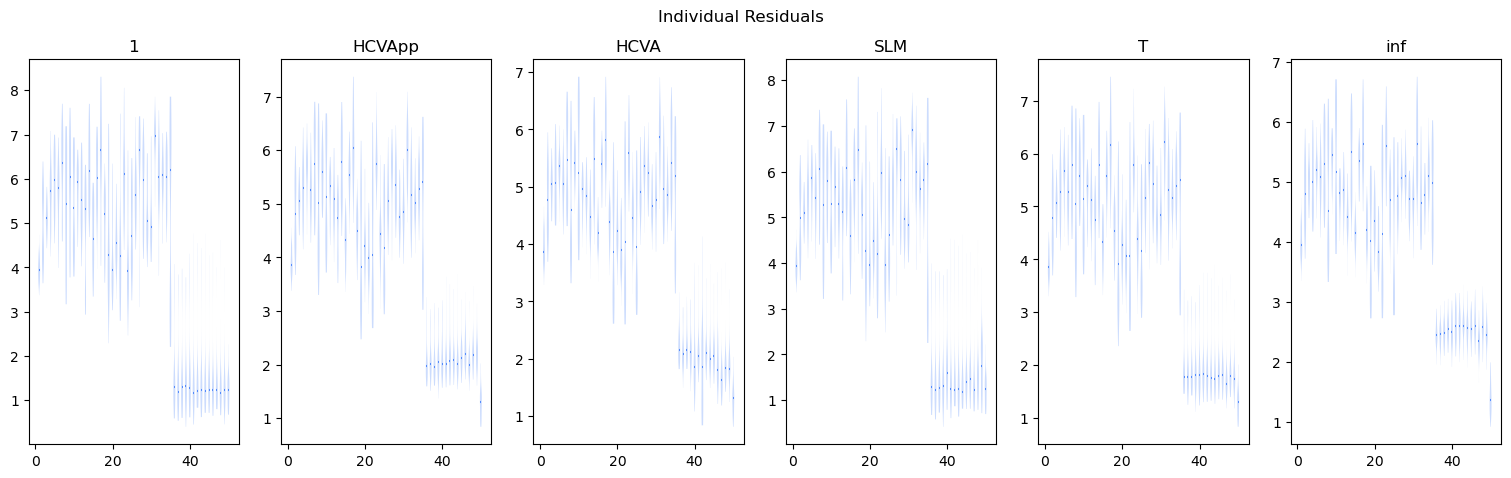

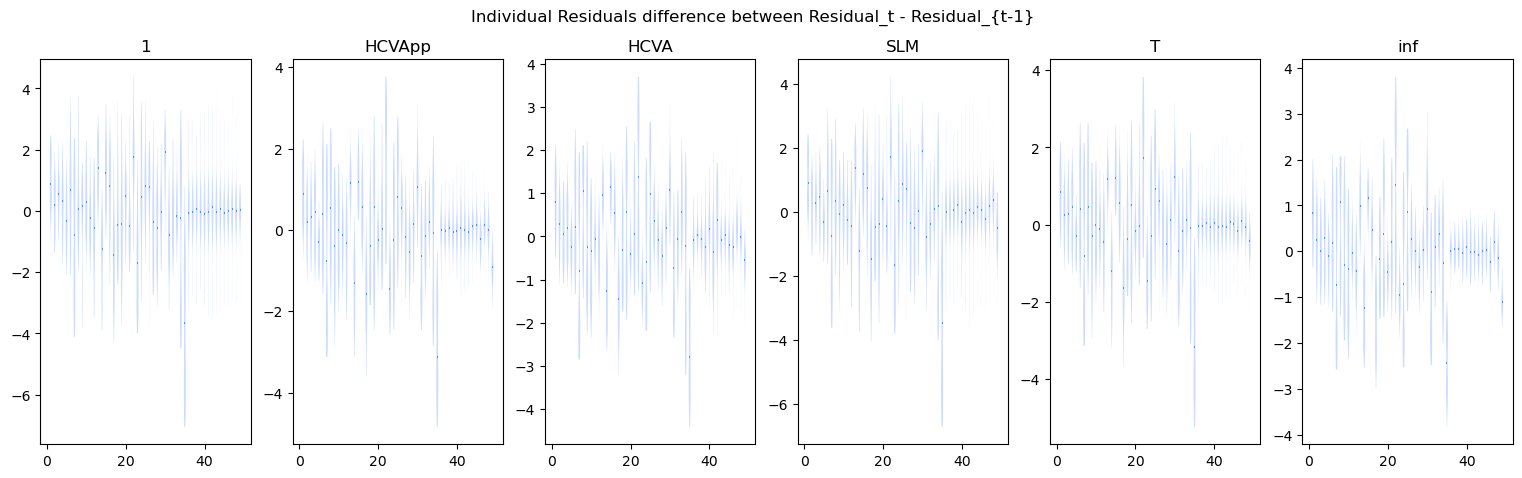

In [7]:
# Plot each row (where col[0] for each df is an ID) onto a violin plot. Overlay for each method and plot as a 3x2 grid
fig_ind, axes_ind = plt.subplots(1, 6,  figsize=(19,5))
fig_ind.suptitle("Individual Residuals")
fig_ind_diff, axes_ind_dff = plt.subplots(1, 6,  figsize=(19,5))
fig_ind_diff.suptitle("Individual Residuals difference between Residual_t - Residual_{t-1}")
for ax_ind, ax_ind_diff, key in zip(axes_ind.flatten(), axes_ind_dff.flatten(), ind_dfs.keys()):
    ax_ind.set_title(key)
    ax_ind_diff.set_title(key)
    ax_ind.violinplot(ind_dfs[key].values, showmeans=False, showmedians=True, showextrema=False)
    ax_ind_diff.violinplot(ind_diff_dfs[key].values, showmeans=False, showmedians=True, showextrema=False)
plt.show()
# This plot shows a violin plot per time step (x), showing the individual agent data that has been averaged over 500 runs.

### Grouped Plots
3. Plot residual and residual differences as an upper or lower quartile